In [35]:
import pandas as pd, matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/gaming_industry_trends.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Game Title               1000 non-null   str    
 1   Genre                    1000 non-null   str    
 2   Platform                 1000 non-null   str    
 3   Release Year             1000 non-null   int64  
 4   Developer                1000 non-null   str    
 5   Revenue (Millions $)     1000 non-null   float64
 6   Players (Millions)       1000 non-null   float64
 7   Peak Concurrent Players  1000 non-null   float64
 8   Metacritic Score         1000 non-null   int64  
 9   Esports Popularity       1000 non-null   str    
 10  Trending Status          1000 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 133.4 KB


In [4]:
df.describe().round(2)

,Release Year,Revenue (Millions $),Players (Millions),Peak Concurrent Players,Metacritic Score
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,2012.07,2483.02,103.50,31.60,74.99
std,7.03,1412.63,58.87,23.02,14.62
min,2000.00,11.43,0.53,0.11,50.00
25%,2006.00,1276.19,52.00,12.97,62.00
50%,2012.00,2476.13,107.04,26.40,76.00
75%,2018.00,3677.80,155.63,46.02,87.00
max,2024.00,4999.79,199.98,96.62,100.00


In [5]:
df['Release Year']

0      2011
1      2018
2      2018
3      2002
4      2018
       ... 
995    2006
996    2016
997    2020
998    2015
999    2016
Name: Release Year, Length: 1000, dtype: int64

In [6]:
print(df)

               Game Title       Genre        Platform  Release Year  \
0            Neon Speed 5    Strategy            Xbox          2011   
1           Cyber Quest 5     Shooter          Mobile          2018   
2        Fantasy Rivals 1    Strategy            Xbox          2018   
3    Warzone Chronicles 5      Horror            Xbox          2002   
4           Cyber Quest 4         RPG              PC          2018   
..                    ...         ...             ...           ...   
995     Battle Warriors 1     Shooter  Cross-Platform          2006   
996     Battle Warriors 4  Simulation     PlayStation          2016   
997    Legends of Valor 3         RPG            Xbox          2020   
998      Galaxy Raiders 4      Sports          Mobile          2015   
999      Galaxy Raiders 1  Simulation     PlayStation          2016   

        Developer  Revenue (Millions $)  Players (Millions)  \
0          Capcom                 52.28               77.99   
1    Bandai Namco    

In [7]:
genre = df['Genre']

In [8]:
genre.unique()

<ArrowStringArray>
[  'Strategy',    'Shooter',     'Horror',        'RPG',     'Sports',
     'Action',  'Adventure',     'Racing',   'Fighting', 'Simulation']
Length: 10, dtype: str

#### Univariate Analysis ####

In [9]:
# year_group_by_genre = df['Genre'].groupby(df['Release Year']).count()

# type(year_group_by_genre) #Series

# year_group_by_genre
revenue_group_by_genre = df.groupby('Genre')['Revenue (Millions $)'].mean().reset_index().round(2)
sorted_revenue_group_by_genre = revenue_group_by_genre.sort_values(by='Revenue (Millions $)', ascending=False)


revenue_group_by_genre
sorted_revenue_group_by_genre


,Genre,Revenue (Millions $)
4,RPG,2716.13
2,Fighting,2649.90
7,Simulation,2554.51
3,Horror,2524.36
1,Adventure,2501.95
5,Racing,2460.28
9,Strategy,2439.55
6,Shooter,2428.93
0,Action,2388.33
8,Sports,2284.36


#### Bivariate Analysis ####

In [36]:
dev_grouped_by_rev = df.groupby("Developer")[["Revenue (Millions $)", 'Release Year']].aggregate('mean')

In [37]:
sorted_dev_grouped_by_rev = dev_grouped_by_rev.reset_index().sort_values(by='Revenue (Millions $)', ascending=False)



In [12]:
sorted_dev_grouped_by_rev.rename(columns={
    'Revenue (Millions $)': 'Revenue (Millions $) - Desc', 
    'Release Year': 'Release Year (Desc)'
}).round(2)

,Developer,Revenue (Millions $) - Desc,Release Year (Desc)
2,Capcom,2697.99,2012.26
7,Sony,2669.30,2011.23
5,Nintendo,2594.49,2011.43
0,Activision,2513.67,2012.45
3,EA,2478.85,2012.64
1,Bandai Namco,2445.07,2012.00
6,Rockstar,2422.76,2011.93
4,Microsoft,2388.45,2012.24
8,Square Enix,2318.55,2011.43
9,Ubisoft,2264.02,2013.17


In [13]:
title_name = df['Game Title']
title_name.head(20)

0             Neon Speed 5
1            Cyber Quest 5
2         Fantasy Rivals 1
3     Warzone Chronicles 5
4            Cyber Quest 4
5     Warzone Chronicles 3
6             Neon Speed 4
7            Cyber Quest 3
8     Warzone Chronicles 1
9             Neon Speed 5
10    Warzone Chronicles 3
11           Cyber Quest 4
12       Zombie Outbreak 4
13           Cyber Quest 1
14        Galaxy Raiders 1
15      Legends of Valor 2
16         Shadow Realms 3
17       Zombie Outbreak 2
18        Galaxy Raiders 5
19    Warzone Chronicles 1
Name: Game Title, dtype: str

In [14]:
title_name.head(75)

0             Neon Speed 5
1            Cyber Quest 5
2         Fantasy Rivals 1
3     Warzone Chronicles 5
4            Cyber Quest 4
              ...         
70           Cyber Quest 3
71    Warzone Chronicles 5
72         Pixel Odyssey 1
73      Legends of Valor 2
74        Fantasy Rivals 1
Name: Game Title, Length: 75, dtype: str

#### Selected Keywords in Game Title #### 
I wanted to observe whether there was any correlation between selected keywords in game titles and market success 
##### Methodology: ##### 
##### Using a for-loop with selected keywords in game titles to include: `Battle`, `Legends`, `Fantasy`, `Shadow`, `Galaxy`, `Zombie`, `Speed` and `War`. ##### 

In [15]:
count_battle = 0
count_legends = 0
count_fantasy = 0
count_shadow = 0
count_galaxy = 0
count_zombie = 0
count_speed = 0
count_war = 0
for name in title_name:
    if 'Battle' in name:
        count_battle += 1 
    elif 'Legends' in name:
        count_legends += 1 
    elif 'Fantasy' in name:
        count_fantasy +=1
    elif 'Shadow' in name:
        count_shadow += 1
    elif 'Galaxy' in name:
        count_galaxy += 1
    elif 'Zombie' in name:
        count_zombie += 1   
    elif 'Speed' in name:
        count_speed += 1     
    elif 'War'in name:
        count_war += 1 

print(f"\'Battle' word count: ", count_battle)  
print(f"\'Fantasy' word count: ", count_fantasy)
print(f"\'Legends' word count: ", count_legends)
print(f"\'Shadow' word count: ", count_shadow)
print(f"\'Galaxy' word count: ", count_galaxy)
print(f"\'Zombie' word count: ", count_zombie)
print(f"\'Speed' word count: ", count_speed)
print(f"\'War' word count: ", count_war)



'Battle' word count:  103
'Fantasy' word count:  100
'Legends' word count:  88
'Shadow' word count:  86
'Galaxy' word count:  98
'Zombie' word count:  95
'Speed' word count:  107
'War' word count:  109


In [16]:
word_count_dictionary = {
    'Battle word count': count_battle,
    'Fantasy word count':count_fantasy,
    'Legends word count': count_legends,
    'Shadow word count': count_shadow,
    'Galaxy word count': count_galaxy,
    'Zombie word count': count_zombie,
    'War word count': count_war,
    'Speed word count': count_speed
} #creating dictionary that will be converted to Dataframe

In [17]:
dict_to_df = pd.DataFrame(list(word_count_dictionary.items()), columns=['KeyWord', 'Count'])

In [18]:
dict_to_df.sort_values(by=['Count'], ascending=False)

,KeyWord,Count
6,War word count,109
7,Speed word count,107
0,Battle word count,103
1,Fantasy word count,100
4,Galaxy word count,98
5,Zombie word count,95
2,Legends word count,88
3,Shadow word count,86


In [19]:
dict_to_df.rename(index={
    0: 'Battle', 
    1: 'Fantasy',
    2: 'Legends',
    3: 'Shadow',
    4: 'Galaxy',
    5: 'Zombie',
    6: 'War',
    7: 'Speed'
    
}, inplace=True) #renaming index to match selected keyword in game title

<Axes: title={'center': 'Frequency of Selected Keywords in Game Titles'}>

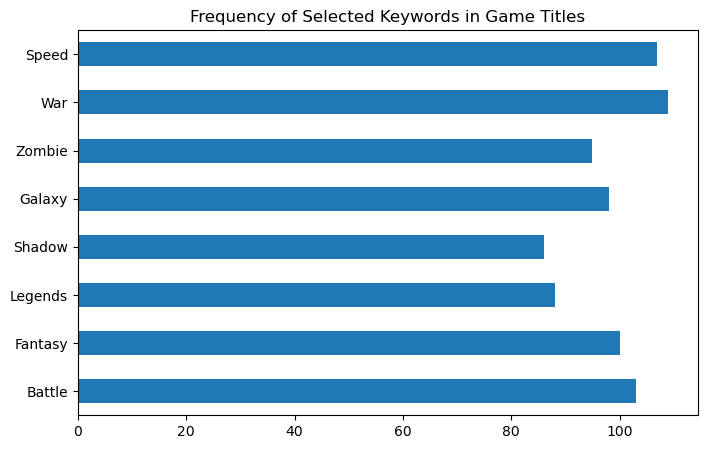

In [20]:
dict_to_df.plot(
    kind='barh', 
    title= 'Frequency of Selected Keywords in Game Titles',
    legend=False,
    figsize= (8,5)
    
)

In [21]:
# pd.pivot_table(
#     data=pd,
#     values=df['Release Year'], index=df['Genre'], columns=df['Revenue (Millions $)'])

#### It looks like with the dataset, there's only 50 unique game titles. We observe that some game titles are re-released in subsequent years, depending on demand. ####

In [22]:
title_name.unique()

<ArrowStringArray>
[        'Neon Speed 5',        'Cyber Quest 5',     'Fantasy Rivals 1',
 'Warzone Chronicles 5',        'Cyber Quest 4', 'Warzone Chronicles 3',
         'Neon Speed 4',        'Cyber Quest 3', 'Warzone Chronicles 1',
    'Zombie Outbreak 4',        'Cyber Quest 1',     'Galaxy Raiders 1',
   'Legends of Valor 2',      'Shadow Realms 3',    'Zombie Outbreak 2',
     'Galaxy Raiders 5',      'Shadow Realms 5',        'Cyber Quest 2',
         'Neon Speed 3',      'Shadow Realms 4',      'Shadow Realms 2',
         'Neon Speed 1',     'Fantasy Rivals 3',   'Legends of Valor 1',
      'Pixel Odyssey 1',    'Battle Warriors 2', 'Warzone Chronicles 4',
     'Galaxy Raiders 4',     'Galaxy Raiders 3',    'Battle Warriors 5',
    'Zombie Outbreak 3',    'Battle Warriors 1',     'Fantasy Rivals 2',
     'Fantasy Rivals 4',   'Legends of Valor 5',      'Pixel Odyssey 3',
         'Neon Speed 2',      'Pixel Odyssey 2',      'Shadow Realms 1',
   'Legends of Valor 3',   'Lege

In [23]:
title_name.to_frame()


,Game Title
0,Neon Speed 5
1,Cyber Quest 5
2,Fantasy Rivals 1
3,Warzone Chronicles 5
4,Cyber Quest 4
...,...
995,Battle Warriors 1
996,Battle Warriors 4
997,Legends of Valor 3
998,Galaxy Raiders 4


In [24]:
game_title_year = title_name.to_frame()
game_title_year

,Game Title
0,Neon Speed 5
1,Cyber Quest 5
2,Fantasy Rivals 1
3,Warzone Chronicles 5
4,Cyber Quest 4
...,...
995,Battle Warriors 1
996,Battle Warriors 4
997,Legends of Valor 3
998,Galaxy Raiders 4


In [25]:
df

,Game Title,Genre,Platform,Release Year,Developer,Revenue (Millions $),Players (Millions),Peak Concurrent Players,Metacritic Score,Esports Popularity,Trending Status
0,Neon Speed 5,Strategy,Xbox,2011,Capcom,52.28,77.99,21.44,69,No,Stable
1,Cyber Quest 5,Shooter,Mobile,2018,Bandai Namco,4345.97,65.28,11.22,72,No,Stable
2,Fantasy Rivals 1,Strategy,Xbox,2018,Microsoft,1278.29,160.09,48.40,51,Yes,Declining
3,Warzone Chronicles 5,Horror,Xbox,2002,Microsoft,361.26,98.14,32.96,91,No,Declining
4,Cyber Quest 4,RPG,PC,2018,EA,4549.27,199.47,58.39,74,No,Stable
...,...,...,...,...,...,...,...,...,...,...,...
995,Battle Warriors 1,Shooter,Cross-Platform,2006,Rockstar,1262.82,79.69,15.90,99,No,Rising
996,Battle Warriors 4,Simulation,PlayStation,2016,Capcom,367.94,152.19,28.36,68,Yes,Declining
997,Legends of Valor 3,RPG,Xbox,2020,Microsoft,2547.81,83.77,22.98,59,Yes,Rising
998,Galaxy Raiders 4,Sports,Mobile,2015,Ubisoft,2737.73,31.27,13.03,61,Yes,Declining


In [26]:
rel_year_grouped_game_title = df.groupby('Game Title')['Release Year'].count()

In [27]:
rel_year_grouped_game_title #row counts

Game Title
Battle Warriors 1       25
Battle Warriors 2       14
Battle Warriors 3       25
Battle Warriors 4       15
Battle Warriors 5       24
Cyber Quest 1           23
Cyber Quest 2           25
Cyber Quest 3           27
Cyber Quest 4           16
Cyber Quest 5           24
Fantasy Rivals 1        17
Fantasy Rivals 2        24
Fantasy Rivals 3        22
Fantasy Rivals 4        23
Fantasy Rivals 5        14
Galaxy Raiders 1        17
Galaxy Raiders 2        22
Galaxy Raiders 3        15
Galaxy Raiders 4        21
Galaxy Raiders 5        23
Legends of Valor 1      16
Legends of Valor 2      22
Legends of Valor 3      18
Legends of Valor 4      19
Legends of Valor 5      13
Neon Speed 1            19
Neon Speed 2            20
Neon Speed 3            21
Neon Speed 4            27
Neon Speed 5            20
Pixel Odyssey 1         24
Pixel Odyssey 2         15
Pixel Odyssey 3         15
Pixel Odyssey 4         23
Pixel Odyssey 5         22
Shadow Realms 1         14
Shadow Realms 2  

In [28]:
rel_year_grouped_game_title.to_frame().reset_index()

,Game Title,Release Year
0,Battle Warriors 1,25
1,Battle Warriors 2,14
2,Battle Warriors 3,25
3,Battle Warriors 4,15
4,Battle Warriors 5,24
5,Cyber Quest 1,23
6,Cyber Quest 2,25
7,Cyber Quest 3,27
8,Cyber Quest 4,16
9,Cyber Quest 5,24


In [29]:
titles_sort = df['Game Title'].sort_values(ascending=True)

In [30]:
titles_sort

49     Battle Warriors 1
93     Battle Warriors 1
106    Battle Warriors 1
155    Battle Warriors 1
274    Battle Warriors 1
             ...        
691    Zombie Outbreak 5
801    Zombie Outbreak 5
821    Zombie Outbreak 5
904    Zombie Outbreak 5
968    Zombie Outbreak 5
Name: Game Title, Length: 1000, dtype: str

In [31]:
popularity_by_year = df.groupby(['Release Year', 'Game Title']).size().reset_index(name='Count')

In [39]:
popularity_by_year.head

<bound method NDFrame.head of      Release Year            Game Title  Count
0            2000     Battle Warriors 2      1
1            2000     Battle Warriors 3      1
2            2000     Battle Warriors 5      2
3            2000         Cyber Quest 2      1
4            2000         Cyber Quest 4      1
..            ...                   ...    ...
678          2024       Shadow Realms 5      1
679          2024  Warzone Chronicles 1      1
680          2024  Warzone Chronicles 2      2
681          2024  Warzone Chronicles 5      1
682          2024     Zombie Outbreak 4      3

[683 rows x 3 columns]>

In [33]:
popularity_by_year.min()

Release Year                 2000
Game Title      Battle Warriors 1
Count                           1
dtype: object

In [34]:
popularity_by_year.max()

Release Year                 2024
Game Title      Zombie Outbreak 5
Count                           4
dtype: object